## Unsupervised Analysis of Killer Whale Calls

**IISER Advanced Bioacoustics Workshop**

*February 3rd, 2026*

In [1]:
## --- import some libraries --- ##

import numpy as np  # for numerical calculations
import pandas as pd  # for working with csv files and data frames
from matplotlib import pyplot as plt  # for plotting and visualization
import datetime # for parsing and formatting date/time data
import umap

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### Formatting

First, parse and re-format the BirdNET embedding files to a format read by the Tensorflow visualizer.

In [2]:
# load in the BirdNET embeddings and take a look at them
embeddings_file = '../Data/embeddings.csv'
embeddings = pd.read_csv(embeddings_file, sep=',')
embeddings.head()

,file_path,start,end,embedding
0,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.03765869140625,0.63134765625,0.0530395507812..."
1,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.247314453125,0.6484375,0.216064453125,0.0598..."
2,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.086669921875,0.145751953125,0.32568359375,0...."
3,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.03326416015625,0.59814453125,0.1280517578125..."
4,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.08770751953125,0.7216796875,0.184814453125,0..."


In [4]:
# extract the numerical part into a matrix, and save to a txt file
numbers = embeddings['embedding']
numbers = np.array([[float(x) for x in num.split(',')] for num in numbers])
np.savetxt('../Embeddings/embedding_values.tsv', numbers, delimiter='\t')

FileNotFoundError: [Errno 2] No such file or directory: '../Embeddings/embedding_values.tsv'

In [4]:
# parse and reformat the metadata
def parseMetadata(filename):
    split_path = filename.split('/')
    split_filename = split_path[9].split('_')
    category = split_filename[-1][:-4]
    day = split_filename[0]
    channel = split_filename[2]
    time = split_filename[3][:-1]
    return category, day, channel, time

# apply parsing function
metadata = pd.DataFrame(embeddings['file_path'].apply(parseMetadata).tolist())

# set columns names
metadata.columns = ['Category', 'Day', 'Channel', 'Time']

# save to tab-separated file
metadata.to_csv('metadata.tsv', sep='\t', index=False)

### Calculate and Visualize Projections

In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# also import some more plotting tools
import matplotlib as mpl
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

Next, calculate PCA projection:

In [22]:
projection_pca = PCA(n_components=2).fit_transform(numbers)

Calculate t-SNE projection:

In [25]:
projection_tsne = TSNE(n_components=2).fit_transform(numbers)

Calculate UMAP projection:

In [ ]:
projection_umap = umap.UMAP(n_components=2).fit_transform(numbers)

Now plot and visualize the output, considering the relative distribution and tightness of clusters.

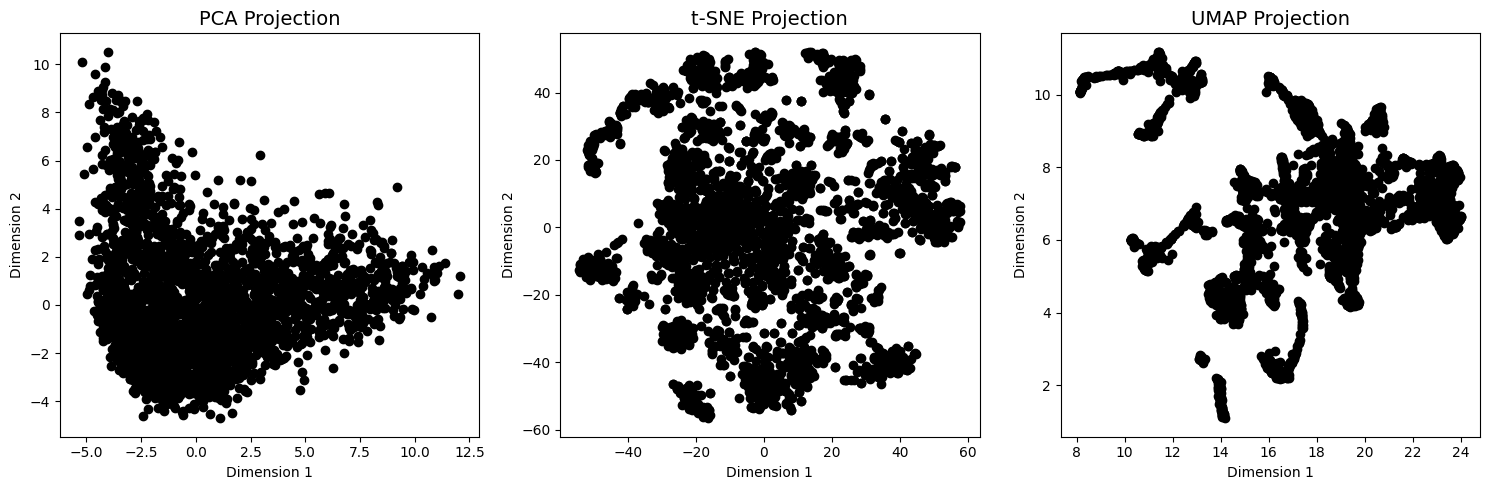

In [29]:
methods = ['PCA', 't-SNE', 'UMAP']
projections = {'PCA': projection_pca, 't-SNE': projection_tsne, 'UMAP': projection_umap}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axs[i].scatter(projections[methods[i]][:, 0], projections[methods[i]][:, 1], c='k', marker='o')
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)

plt.tight_layout()

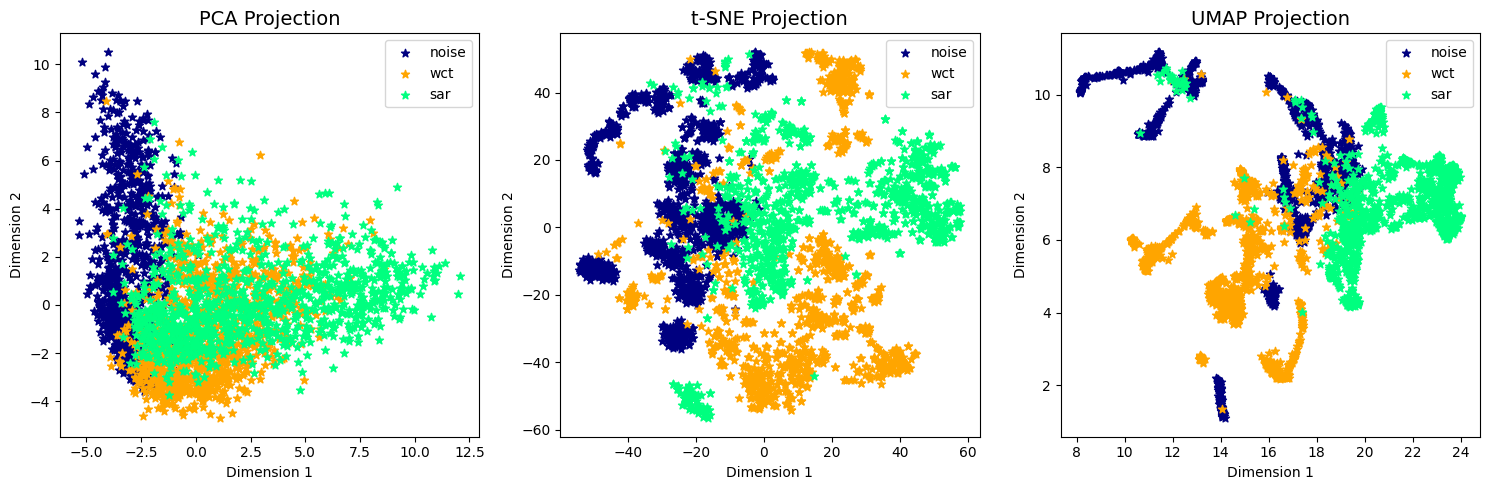

In [40]:
colors = {'noise': 'navy', 'wct': 'orange', 'sar': 'springgreen'}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    for category in ['noise', 'wct', 'sar']:
        axs[i].scatter(projections[methods[i]][metadata['Category'] == category, 0], projections[methods[i]][metadata['Category'] == category, 1], c=colors[category], marker='*', label=category)
    
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)
    axs[i].legend()

plt.tight_layout()

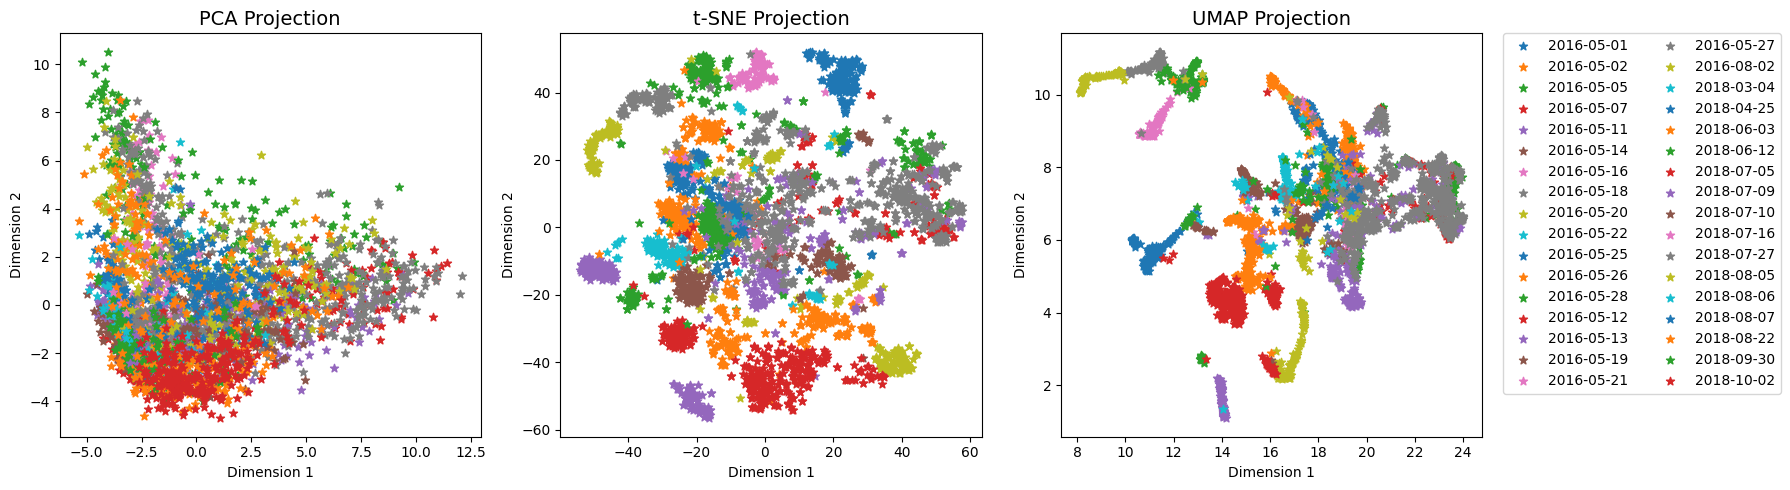

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    for day in metadata['Day'].unique():
        axs[i].scatter(projections[methods[i]][metadata['Day'] == day, 0], projections[methods[i]][metadata['Day'] == day, 1], marker='*', label=datetime.datetime.strptime(day, '%Y%m%d').strftime('%Y-%m-%d'))
    
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., ncol=2)
plt.tight_layout()

### Perform Denoising with Spectral Subtraction

In [42]:
import scipy.signal

In [43]:
def logTransform(spec, scale=10**(-5)):
    return 20 * np.log10(spec + scale * np.ones(spec.shape))

In [44]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    cutoff = 2 * np.array([lowcut, highcut]) / fs
    b, a = scipy.signal.butter(order, cutoff, btype='band', analog=False)
    y = scipy.signal.filtfilt(b, a, data)
    return y

In [ ]:
def spectralSubtraction(signal, sr, nfft=1024, PLOT=False):
    # filter
    signal = butter_bandpass_filter(signal, 200, 10000, sr, order=5)

    # calculate spectrogram
    freqs, inds, spec = scipy.signal.stft(signal, fs=sr, nperseg=nfft, noverlap=nfft//2)

    # apply denoising
    phase = np.angle(spec)
    magnitude = np.abs(spec)
    magnitude = np.maximum(magnitude - np.mean(magnitude, axis=0), 0)
    magnitude = np.maximum(magnitude.T - np.mean(magnitude, axis=1), 0).T

    new_spec = np.empty(shape=spec.shape, dtype=np.complex128)
    new_spec.real = magnitude * np.cos(phase)
    new_spec.imag = magnitude * np.sin(phase)
    new_spec[np.abs(new_spec) < 5 * np.mean(np.abs(new_spec))] = 0

    print(np.median(np.abs(new_spec)), np.mean(np.abs(new_spec)))

    # get back audio-domain representation
    _, denoised_signal = scipy.signal.istft(new_spec, fs=sr, nperseg=nfft, noverlap=nfft//2)

    denoised_signal = butter_bandpass_filter(denoised_signal, 200, 10000, sr, order=5)

    denoised_freqs, denoised_inds, denoised_spec = scipy.signal.stft(denoised_signal, fs=sr, nperseg=nfft, noverlap=3 * nfft//4)

    if PLOT:
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.pcolormesh(inds, freqs, logTransform(np.abs(spec)))
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.ylim(0, 4000)
        #plt.title(filename, fontsize=11)
        plt.subplot(1, 2, 2)
        plt.pcolormesh(denoised_inds, denoised_freqs, logTransform(np.abs(denoised_spec)))
        plt.ylabel('Frequency [Hz]')
        plt.xlabel('Time [sec]')
        plt.ylim(0, 4000)
        #plt.title(filename, fontsize=11)
        plt.tight_layout()

    return denoised_signal

### Calculate and Visualize Projections with Denoising

In [105]:
import soundfile
import os

In [108]:
audio_files = os.listdir('Audio')

In [109]:
audio_files[0]

'20160518_153007_Ch1_98s_noise.wav'

In [ ]:
for audio_file in audio_files:
    signal, sr = soundfile.read(sample_filename, samplerate=None)
    denoised_signal = spectralSubtraction(signal, sr)
    soundfile.write(sample_filename.replace('Audio/', 'DenoisedAudio/'), denoised_signal, sr)

In [ ]:
sample_filename = 'Audio/20160512_234836_Ch1_211s_sar.wav'

signal, sr = soundfile.read(sample_filename, samplerate=None)

soundfile.write(sample_filename.replace('.wav', '_denoised.wav'), denoised_signal, sr)

In [102]:
signal, sr = soundfile.read(sample_filename, samplerate=None)

20160518_153007_Ch1_98s_noise.wav
0.0 1.648838648710341e-05
20160513_001837_Ch1_97s_sar.wav
0.0 4.544486690260302e-06
20180822_114739_Ch1_193s_wct.wav
0.0 4.5248022362589536e-06
20181002_193720_Ch1_232s_wct.wav
0.0 9.820193255872367e-07
20180807_122505_Ch1_261s_wct.wav
0.0 2.7504250293467207e-06
20160513_000337_Ch1_292s_sar.wav
0.0 4.58193842135438e-06
20181002_191219_Ch1_231s_wct.wav
0.0 1.2831085057496842e-06
20181002_192720_Ch1_163s_wct.wav
0.0 1.2503134442677198e-06
20160516_093147_Ch1_21s_noise.wav
0.0 3.101806038109703e-06
20181002_191219_Ch1_230s_wct.wav
0.0 1.1227805421910286e-06


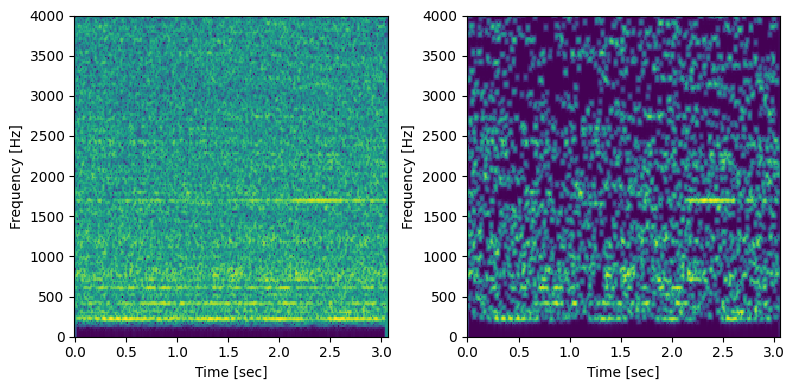

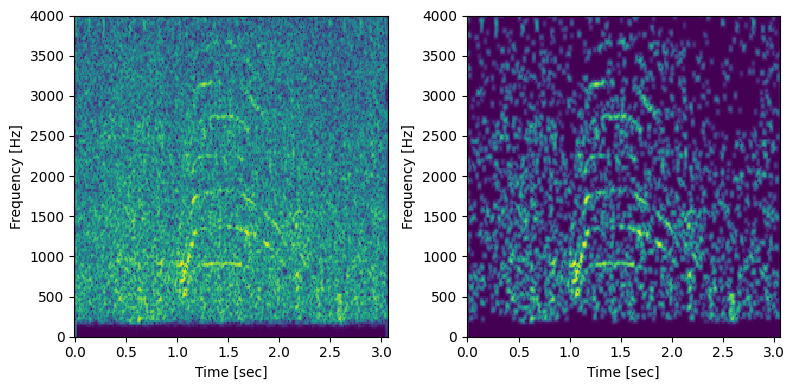

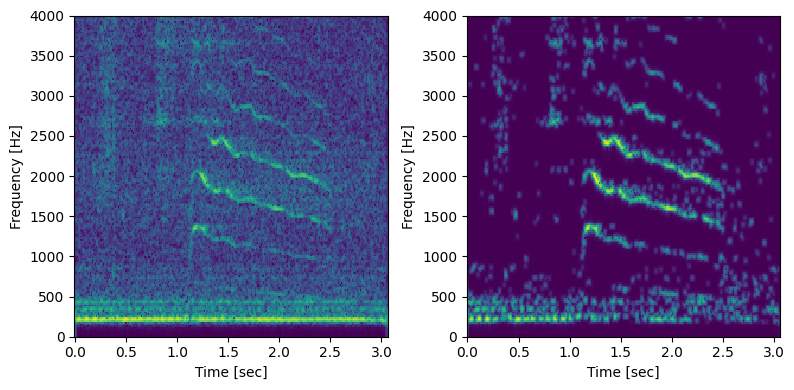

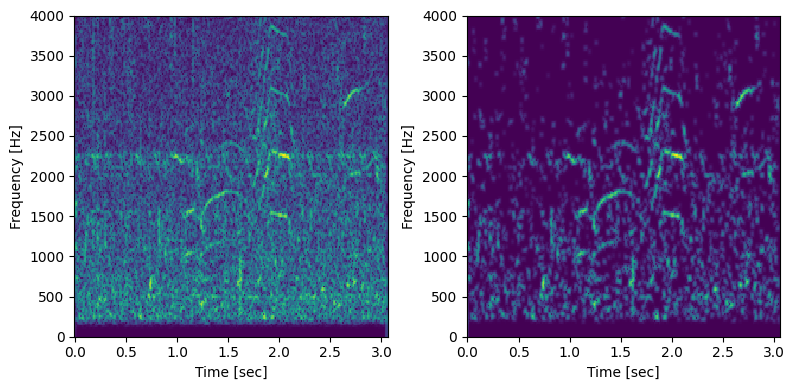

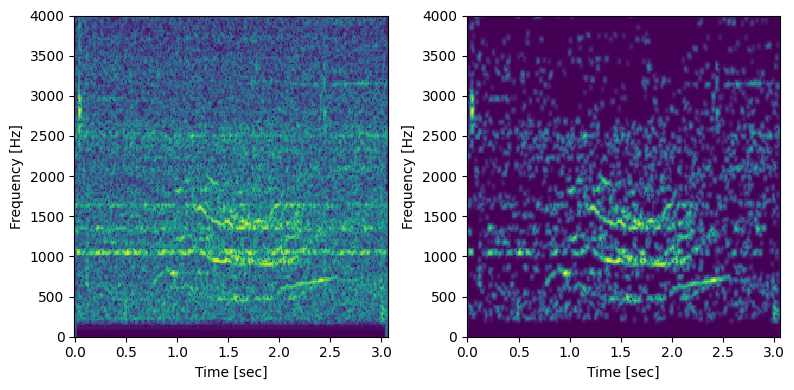

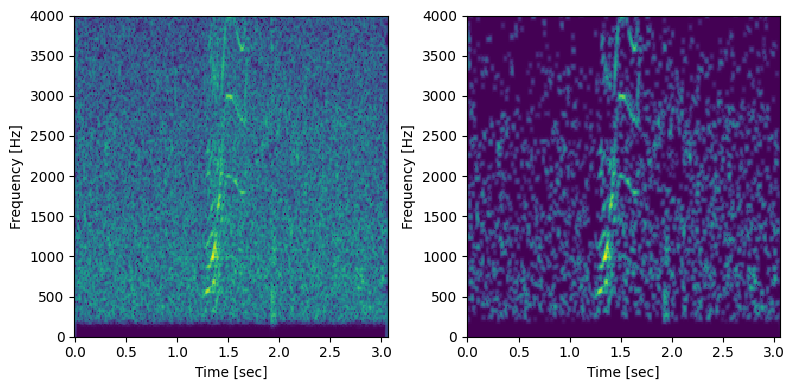

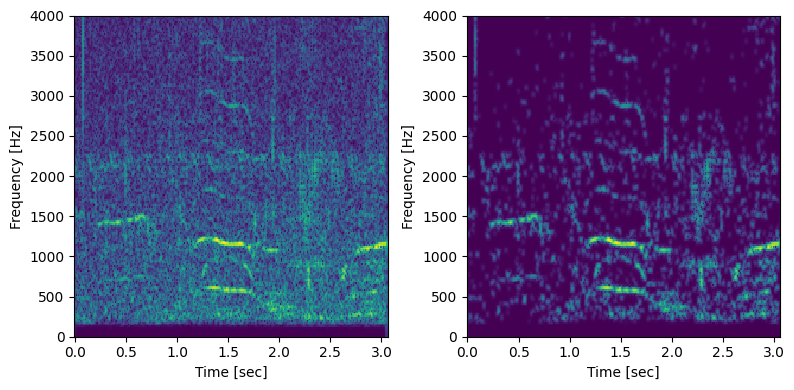

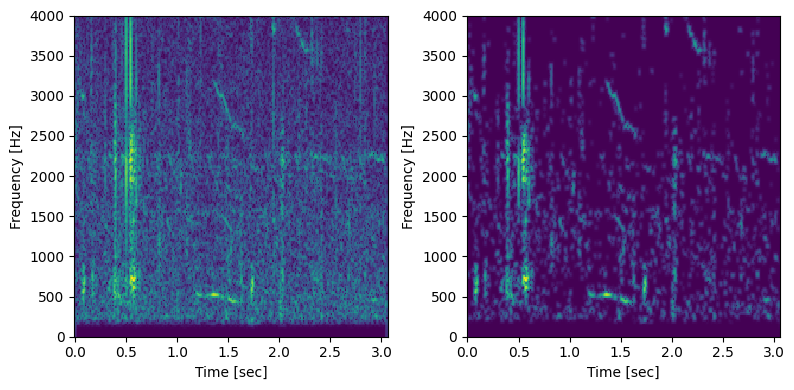

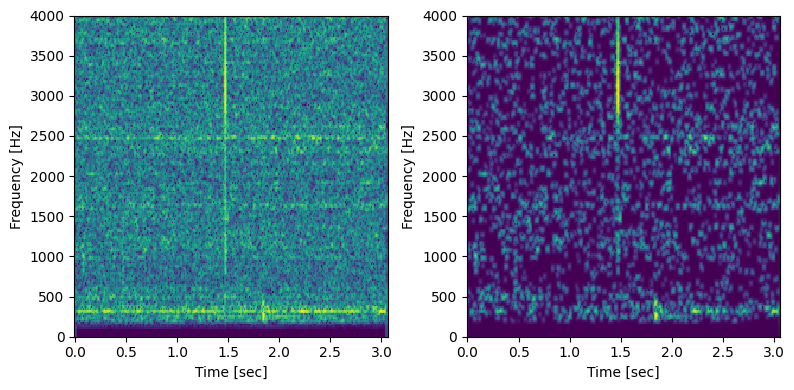

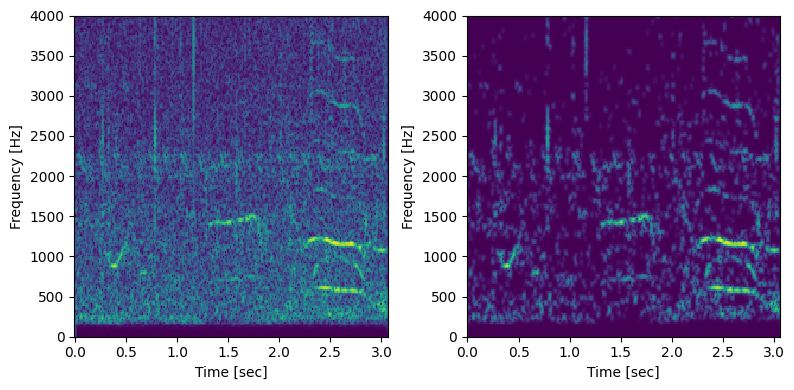

In [111]:
for audio_file in audio_files[0:10]:
    signal, sr = soundfile.read('Audio/' + audio_file, samplerate=None)
    print(audio_file)
    denoised_signal = spectralSubtraction(signal, sr, PLOT=True)

0.0 1.6658950960343866e-05


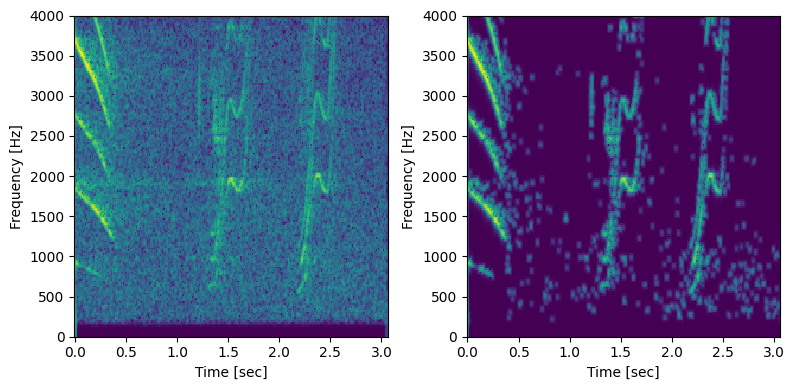

In [103]:
denoised_signal = spectralSubtraction(signal, sr, PLOT=True)
soundfile.write(sample_filename.replace('.wav', '_denoised.wav'), denoised_signal, sr)

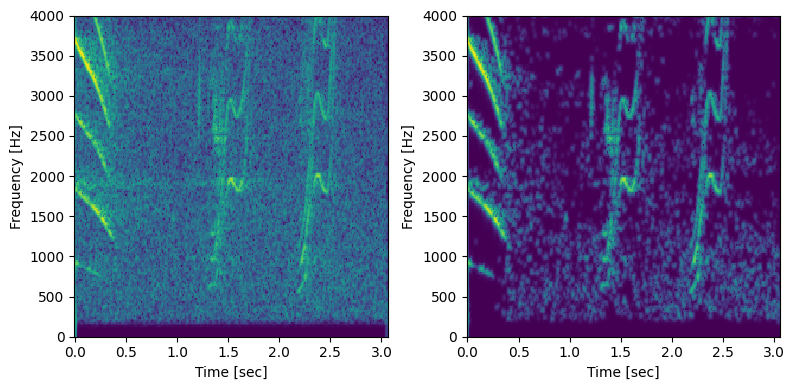

In [81]:
denoised_signal = spectralSubtraction(signal, sr, PLOT=True)

In [71]:
len(dt)/sr

3.053424036281179